In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    #for filename in filenames:
    #    print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___healthy
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Bacterial_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Septoria_leaf_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Early_blight
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Target_Spot
/kaggle/inpu

# Plant Disease Classification - Exploratory Data Analysis

## Objective

The goal of this notebook is to understand the PlantVillage dataset before model development. We will:

- Examine the dataset structure.
- Analyze class distribution.
- Visualize sample images.
- Inspect image dimensions.
- Detect missing or corrupted images.
- Summarize findings to guide preprocessing decisions.

In [3]:
pip install Pillow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
from PIL import Image

from collections import Counter

plt.style.use("ggplot")

In [5]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

In [6]:
classes = sorted(os.listdir(dataset_path))

print("Total Classes:", len(classes))

Total Classes: 15


In [7]:
image_counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    image_counts[cls] = len(os.listdir(folder))

df = pd.DataFrame({
    "Class" : image_counts.keys(),
    "Images" : image_counts.values()
})

df

,Class,Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


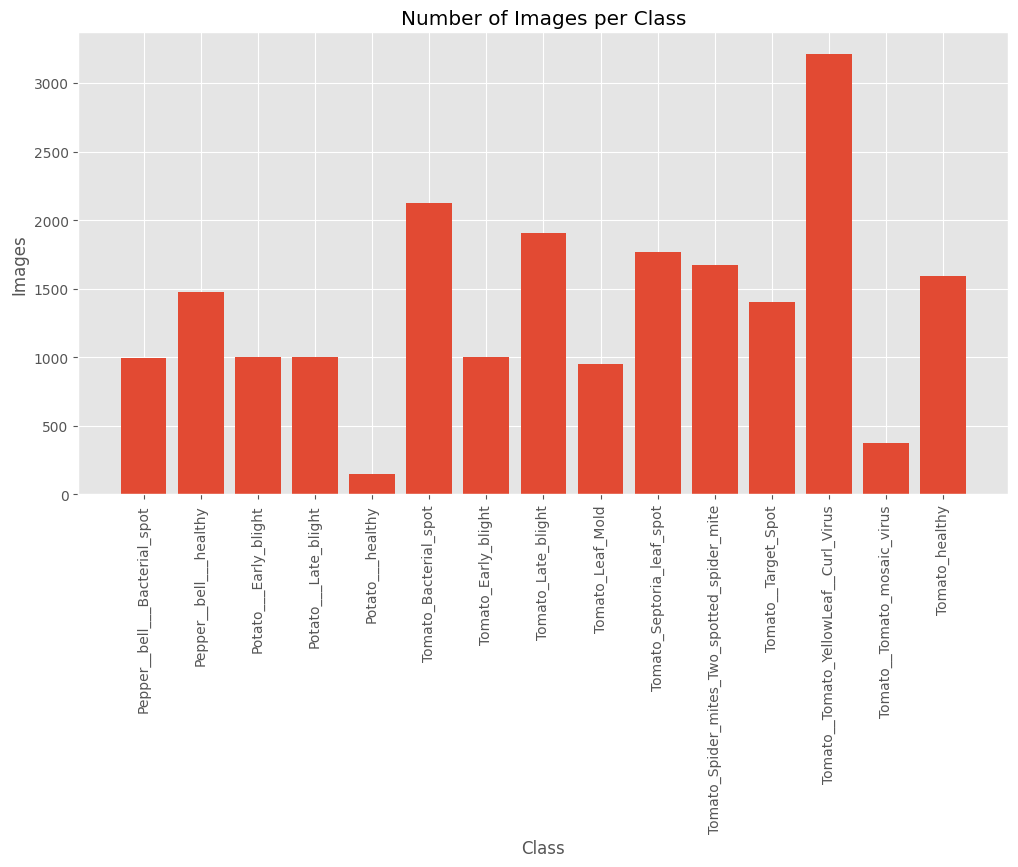

In [8]:
plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Images"])

plt.xticks(rotation=90)

plt.title("Number of Images per Class")

plt.xlabel("Class")

plt.ylabel("Images")

plt.show()

Class Distribution Analysis:
The dataset contains 15 classes with a noticeable class imbalance. While most disease categories have between 900 and 3200 images, a few classes (e.g., healthy potato leaves) have substantially fewer samples. To reduce bias during training, class weights and data augmentation will be applied during preprocessing.

In [9]:
print("Total Images:", df["Images"].sum())

print("Average Images per Class:", round(df["Images"].mean()))

print("Minimum Images:", df["Images"].min())

print("Maximum Images:", df["Images"].max())

Total Images: 20639
Average Images per Class: 1376
Minimum Images: 152
Maximum Images: 3209


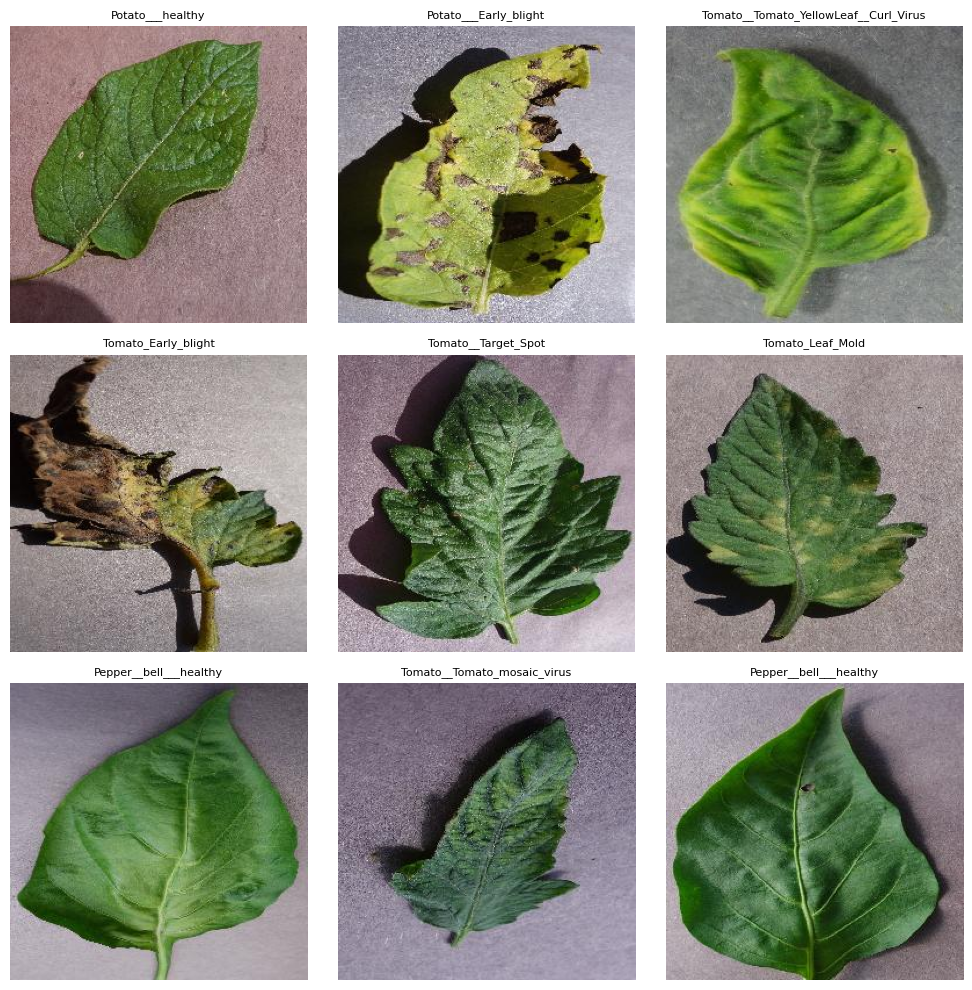

In [11]:
#Display Random Images

import random

fig, axes = plt.subplots(3, 3, figsize=(10,10))

for ax in axes.ravel():

    cls = random.choice(classes)

    folder = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(folder))

    img = Image.open(os.path.join(folder, img_name))

    ax.imshow(img)

    ax.set_title(cls, fontsize=8)

    ax.axis("off")

plt.tight_layout()

In [17]:
#Check Image Sizes

sizes = []

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

         if not img_name.lower().endswith(valid_extensions):
            continue

         img_path = os.path.join(folder, img_name)
    
         img = Image.open(img_path)
    
         sizes.append(img.size)

Counter(sizes).most_common(10)

[((256, 256), 20638)]

In [14]:
#Corrupted Images

bad_images = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        try:
            Image.open(path).verify()

        except Exception:
            bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 1


### Observations

- The dataset contains **20,638 images** across **15 classes**.
- All valid images have a uniform resolution of **256 × 256 pixels**.
- One corrupted/non-readable image was detected.
- Corrupted files will be excluded during data loading to ensure robust model training.